In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2008-2019_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 11, 
years: 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 


In [5]:
r_u = 0.05
near_u = 0.35
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2008_2019.csv'

In [6]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2008-01-01,veneto,abano terme,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"19,349",46.86645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
1,12.04940,45.07048,2008-01-01,veneto,adria,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"20,233",46.65336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.0,1.399263,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
2,10.77673,45.55680,2008-01-01,veneto,affi,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"2,297",46.81410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,7,0,0
3,11.96539,45.17531,2008-01-01,veneto,agna,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"3,400",46.73306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,4,0,0
4,12.05912,46.31399,2008-01-01,veneto,agordo,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,14,0,0


In [7]:
dataset = dataset.query('month >= 6 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [8]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2008-06-01,veneto,abano terme,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"19,349",46.86645,0.328023,0.080399,-0.263422,-0.080399,0.363412,0.099211,-0.262222,-0.099211,0.055560,0.050767,0.021376,0.050767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.000000,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,2,0
1,12.04940,45.07048,2008-06-01,veneto,adria,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"20,233",46.65336,0.294697,0.065611,-0.254850,-0.065611,0.331777,0.095893,-0.252759,-0.095893,0.111285,0.121105,0.024888,0.121105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.000000,1.399263,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,2,0
2,10.77673,45.55680,2008-06-01,veneto,affi,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"2,297",46.81410,0.453163,0.214368,-0.218987,-0.214368,0.498889,0.203807,-0.264907,-0.203807,0.053675,0.050346,0.024386,0.050346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.000000,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,7,14,0
3,11.96539,45.17531,2008-06-01,veneto,agna,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"3,400",46.73306,0.330621,0.065681,-0.279323,-0.065681,0.332201,0.068339,-0.278148,-0.068339,0.065406,0.061280,0.013125,0.061280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.000000,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,4,8,0
4,12.05912,46.31399,2008-06-01,veneto,agordo,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.000000,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,14,28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82242,12.17878,46.38835,2019-11-16,veneto,zoppe da cadore,16,11,46,2019,-0.101168,-0.994869,-5.000000e-01,0.866025,-0.737833,0.674983,265,47.96042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,25000.599626,346.378682,37,238.788886,1403.106042,162.646151,0.000000,2.557130,15.0,94.0,10.0,96.0,10.0,96.0,5,5.0,6.0,4.0,4.0,2,0,8,16,0
82243,11.49430,45.43798,2019-11-16,veneto,zovencedo,16,11,46,2019,-0.101168,-0.994869,-5.000000e-01,0.866025,-0.737833,0.674983,796,46.86928,0.571322,0.155106,-0.465696,-0.155106,0.548208,0.162205,-0.425753,-0.162205,0.051183,0.051136,0.085044,0.051136,8.62,11.25,5.99,4.295000,-0.508182,11.538000,3.365556,18.535455,6.696667,19.732000,10.316667,227.983651,343.831703,1972.511516,5077.714670,1967.854592,35,131.888403,267.495086,193.006806,0.000000,1.

In [9]:
dataset['lau1'].unique().shape

(571,)

In [10]:
print(f'Number of LAU1 Units in {NUTS2}: {len(dataset.lau1.unique())}')

Number of LAU1 Units in Veneto: 571


In [11]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2008,6851,1,6852,8.33%
1,2009,6846,6,6852,8.33%
2,2010,6845,7,6852,8.33%
3,2011,6843,9,6852,8.33%
4,2012,6823,32,6855,8.33%
5,2013,6826,27,6853,8.33%
6,2014,6850,2,6852,8.33%
7,2015,6851,1,6852,8.33%
8,2016,6843,9,6852,8.33%
9,2017,6837,16,6853,8.33%


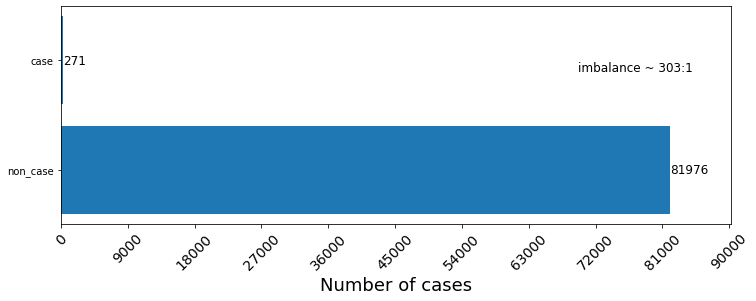

In [12]:
plot_imbalance(dataset)

In [13]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [14]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2008 || w0:1, w1:89 || ##
Year: 2009 || w0:1, w1:91 || ##
Year: 2010 || w0:1, w1:91 || ##
Year: 2011 || w0:1, w1:92 || ##
Year: 2012 || w0:1, w1:100 || ##
Year: 2013 || w0:1, w1:98 || ##
Year: 2014 || w0:1, w1:89 || ##
Year: 2015 || w0:1, w1:89 || ##
Year: 2016 || w0:1, w1:92 || ##
Year: 2017 || w0:1, w1:94 || ##
Year: 2018 || w0:1, w1:165 || ##
Year: 2019 || w0:1, w1:102 || ##


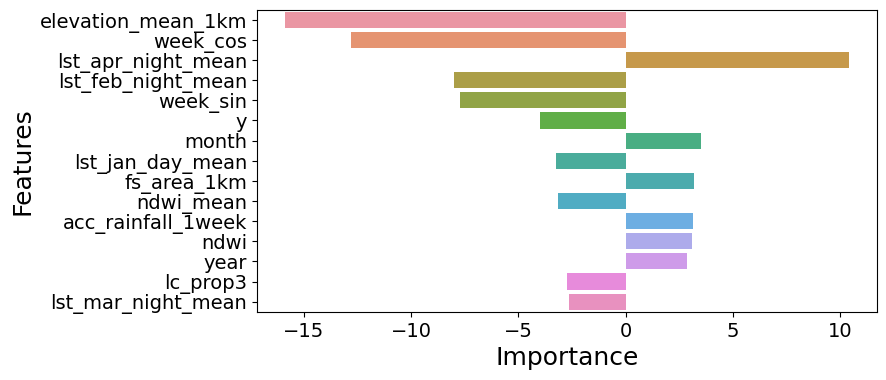

In [15]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

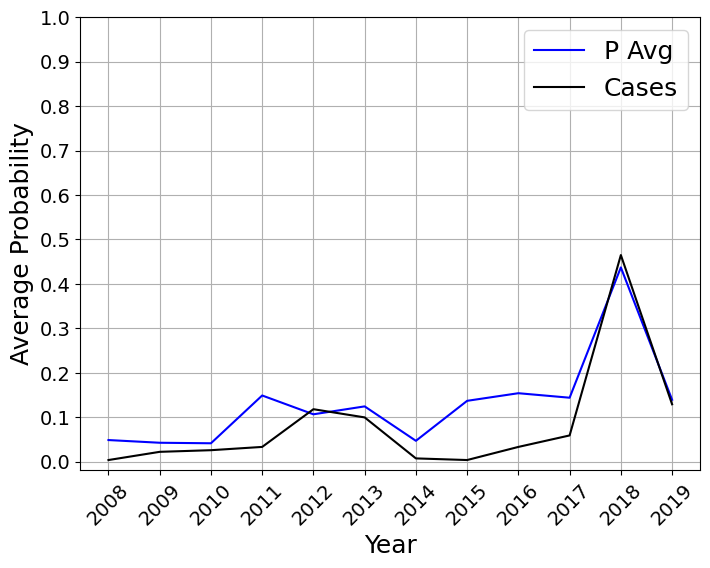

In [16]:
plot_trend_curve(results_test, list(dsc['case']))

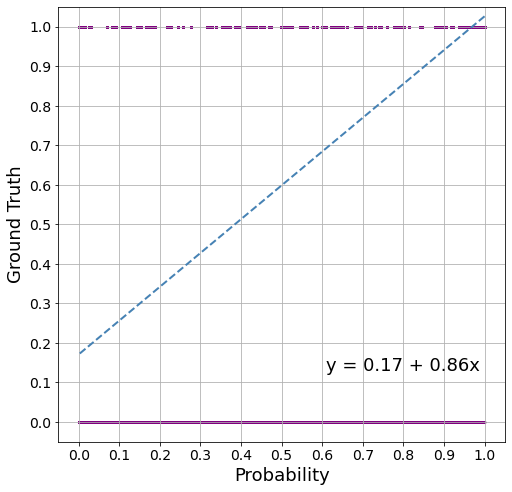

In [17]:
plot_probability_curve(results_test)

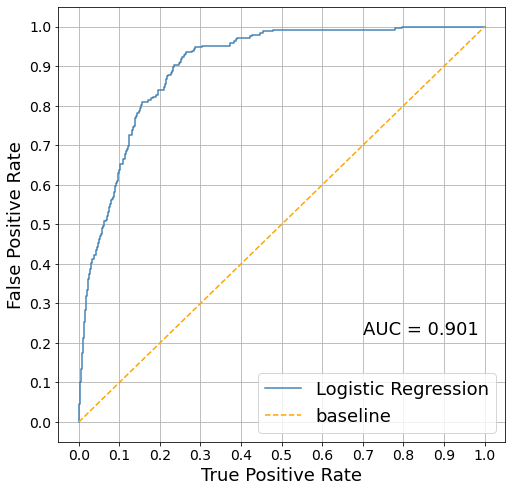

In [18]:
plot_roc_curve(results_test)

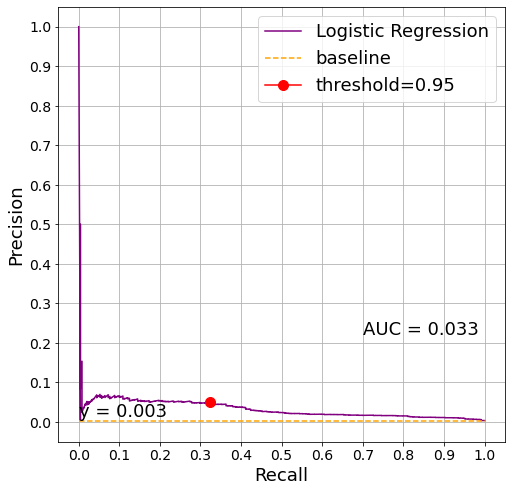

In [19]:
plot_pr_curve(results_test, plot_fbeta = True)


In [20]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 5, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 30.22%
Weighted Average: 29.44%


In [21]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/06/2008,0,0,0,NaN,NaN
1,16/06/2008,0,0,0,NaN,NaN
2,01/07/2008,0,0,0,NaN,NaN
3,16/07/2008,0,0,0,NaN,NaN
4,01/08/2008,0,0,0,NaN,NaN
...,...,...,...,...,...,...
139,16/09/2019,5,0,5,0.00 %,0.0
140,01/10/2019,1,1,1,100.00 %,1.0
141,16/10/2019,0,0,0,NaN,NaN
142,01/11/2019,0,0,0,NaN,NaN


In [22]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2008,1,1,1,100.00 %,1.0000
1,2009,6,3,6,50.00 %,0.5000
2,2010,7,2,7,28.57 %,0.2857
3,2011,9,0,9,0.00 %,0.0000
4,2012,29,5,29,17.24 %,0.1724
5,2013,26,5,26,19.23 %,0.1923
6,2014,2,0,2,0.00 %,0.0000
7,2015,1,0,1,0.00 %,0.0000
8,2016,9,3,9,33.33 %,0.3333
9,2017,15,8,15,53.33 %,0.5333


In [23]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

In [24]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2008,1.0000,0.0737,0.9632,0.0020,1.0000,0.0326,0.0721
1,2009,6.0000,0.0632,0.6352,0.0046,0.3333,0.0643,0.0601
2,2010,7.0000,0.0648,0.4676,0.0000,0.0000,0.0000,0.0611
3,2011,9.0000,0.2564,0.8166,0.0046,0.8889,0.0715,0.2497
4,2012,29.0000,0.2037,0.8306,0.0179,0.8621,0.2285,0.1601
5,2013,26.0000,0.2242,0.7543,0.0124,0.7308,0.1655,0.1980
6,2014,2.0000,0.0734,0.4633,0.0000,0.0000,0.0000,0.0666
7,2015,1.0000,0.2358,0.8821,0.0006,1.0000,0.0104,0.2239
8,2016,9.0000,0.2691,0.8103,0.0043,0.8889,0.0684,0.2576
9,2017,15.0000,0.2408,0.8470,0.0085,0.9333,0.1259,0.2487


In [25]:
results_test

,x,y,municipality,day,month,year,case,probability
0,12.32478,45.43497,venezia,16,8,2018,0,9.999797e-01
1,12.49633,45.47024,cavallino treporti,16,8,2018,1,9.999291e-01
2,12.32478,45.43497,venezia,1,9,2018,0,9.999196e-01
3,12.49633,45.47024,cavallino treporti,1,9,2018,0,9.999130e-01
4,12.30118,45.01592,porto viro,16,8,2018,0,9.999008e-01
...,...,...,...,...,...,...,...,...
82219,11.86525,46.29688,canale da agordo,1,6,2010,0,5.290413e-14
82220,11.49944,45.96164,asiago,16,11,2019,0,4.537513e-14
82221,11.86525,46.29688,canale da agordo,1,11,2010,0,3.426085e-14
82222,11.86525,46.29688,canale da agordo,1,11,2017,0,3.292863e-14
